# Analysis of Forecasted Pollutants vs Ground Truth

This notebook provides a detailed analysis of the raw forecasted pollutant concentrations found in `predictions_pollutants.csv`.
It compares these values against the historical Ground Truth distributions to ensure the model's output is physically realistic.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Config
PRED_PATH = 'predictions_pollutants.csv'
GT_PATH = '../dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.csv'
POLLUTANTS = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']

## 1. Load Data

In [3]:
# Load Predictions
if os.path.exists(PRED_PATH):
    df_pred = pd.read_csv(PRED_PATH, parse_dates=['tanggal'])
    print(f"Forecast Data Loaded: {df_pred.shape}")
else:
    print("Forecast file not found.")

# Load GT
if os.path.exists(GT_PATH):
    df_gt = pd.read_csv(GT_PATH)
    
    # Attempt to Standardize Column Names
    col_map = {
        'pm_sepuluh': 'pm10',
        'pm_duakomalima': 'pm25',
        'sulfur_dioksida': 'so2',
        'karbon_monoksida': 'co',
        'ozon': 'o3',
        'nitrogen_dioksida': 'no2'
    }
    df_gt = df_gt.rename(columns=col_map)
    
    # Numeric Conversion
    for col in POLLUTANTS:
        if col in df_gt.columns:
            df_gt[col] = pd.to_numeric(df_gt[col], errors='coerce')
    
    print(f"Ground Truth Loaded: {df_gt.shape}")
else:
    print("Ground Truth file not found.")

Forecast Data Loaded: (455, 8)
Ground Truth Loaded: (3501, 13)


## 2. Statistical Comparison Table

In [4]:
stats_comparison = []

for col in POLLUTANTS:
    row = {'Pollutant': col}
    
    if col in df_pred.columns:
        row['Pred Mean'] = df_pred[col].mean()
        row['Pred Std'] = df_pred[col].std()
        row['Pred Max'] = df_pred[col].max()
    
    if col in df_gt.columns:
        row['GT Mean'] = df_gt[col].mean()
        row['GT Std'] = df_gt[col].std()
        row['GT Max'] = df_gt[col].max()
        
    stats_comparison.append(row)

df_stats = pd.DataFrame(stats_comparison)
print("Top-level Statistical Comparison:")
display(df_stats.round(2))

Top-level Statistical Comparison:


,Pollutant,Pred Mean,Pred Std,Pred Max,GT Mean,GT Std,GT Max
0,pm10,49.16,6.11,61.26,48.88,16.55,187.0
1,pm25,76.45,9.01,96.12,71.40,23.21,157.0
2,so2,40.32,9.80,61.49,36.03,15.88,112.0
3,co,12.79,2.08,18.43,15.10,6.83,70.0
4,o3,24.99,9.37,53.03,23.79,12.80,115.0
5,no2,32.35,11.19,60.62,27.21,16.67,202.0


## 3. Visual Comparisons (Boxplots)

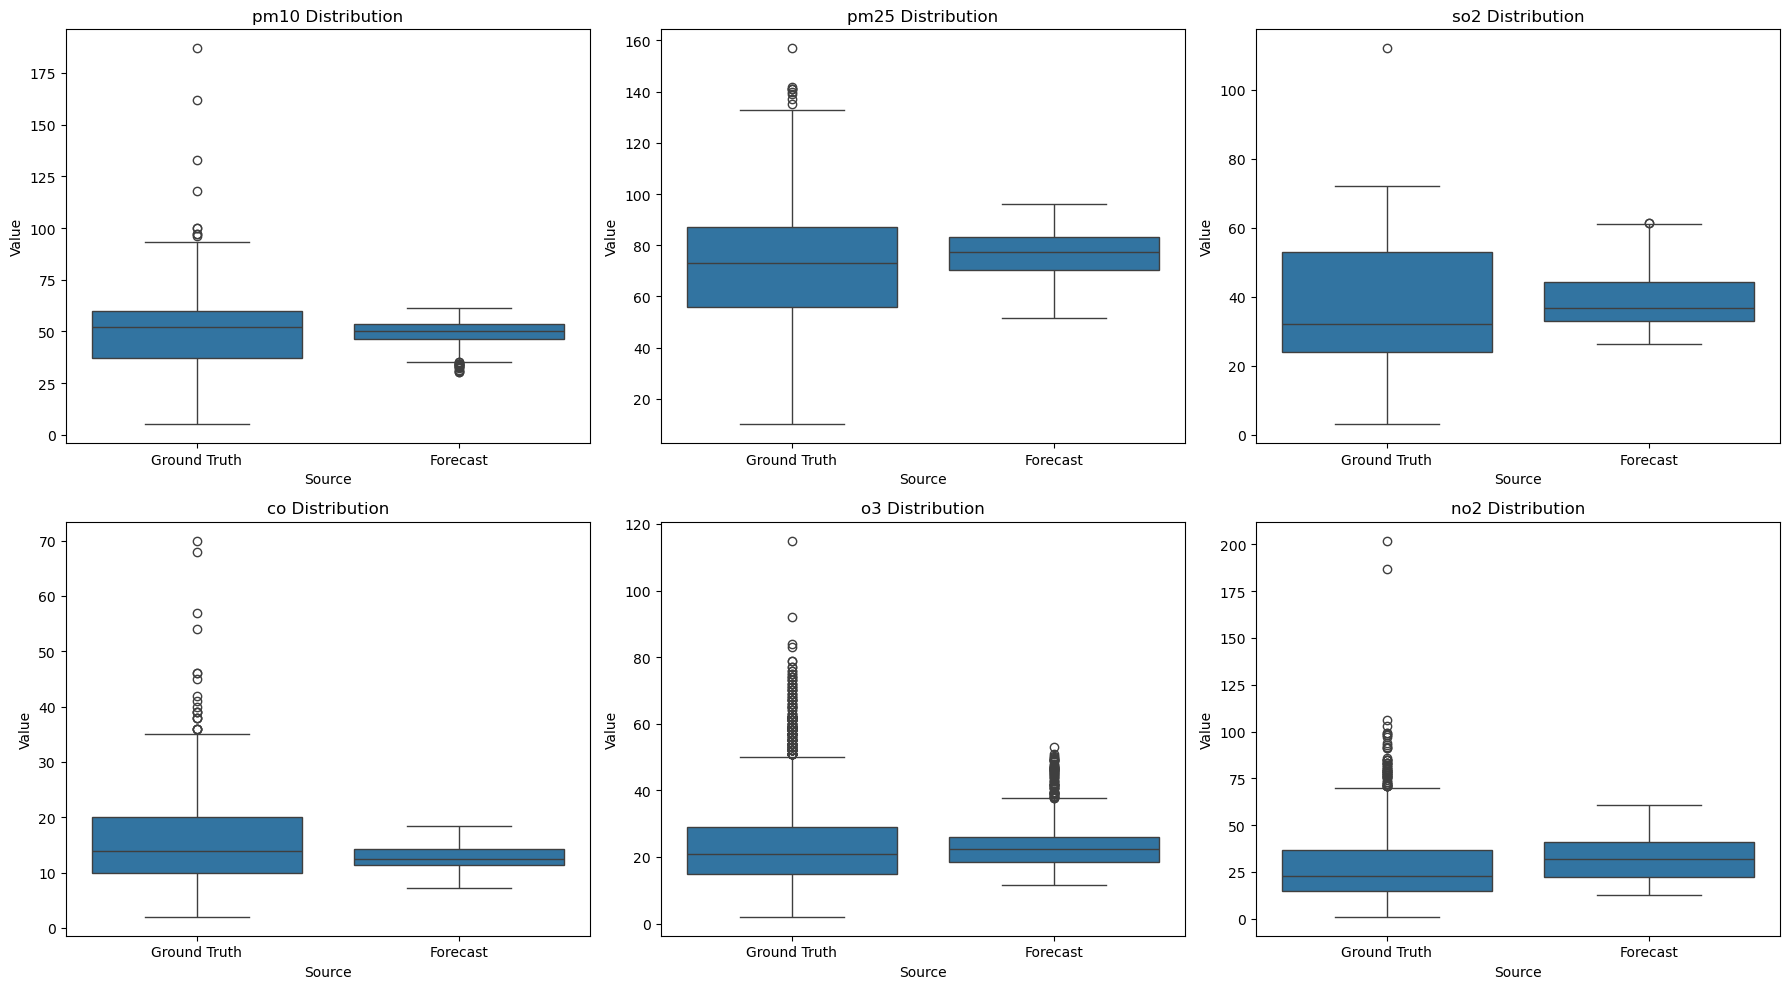

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(POLLUTANTS):
    if col in df_pred.columns and col in df_gt.columns:
        # Create combined DF for plotting
        d1 = pd.DataFrame({'Value': df_gt[col], 'Source': 'Ground Truth'})
        d2 = pd.DataFrame({'Value': df_pred[col], 'Source': 'Forecast'})
        data_plot = pd.concat([d1, d2], ignore_index=True)
        
        sns.boxplot(x='Source', y='Value', data=data_plot, ax=axes[i])
        axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

## 4. Time Series Forecast Preview

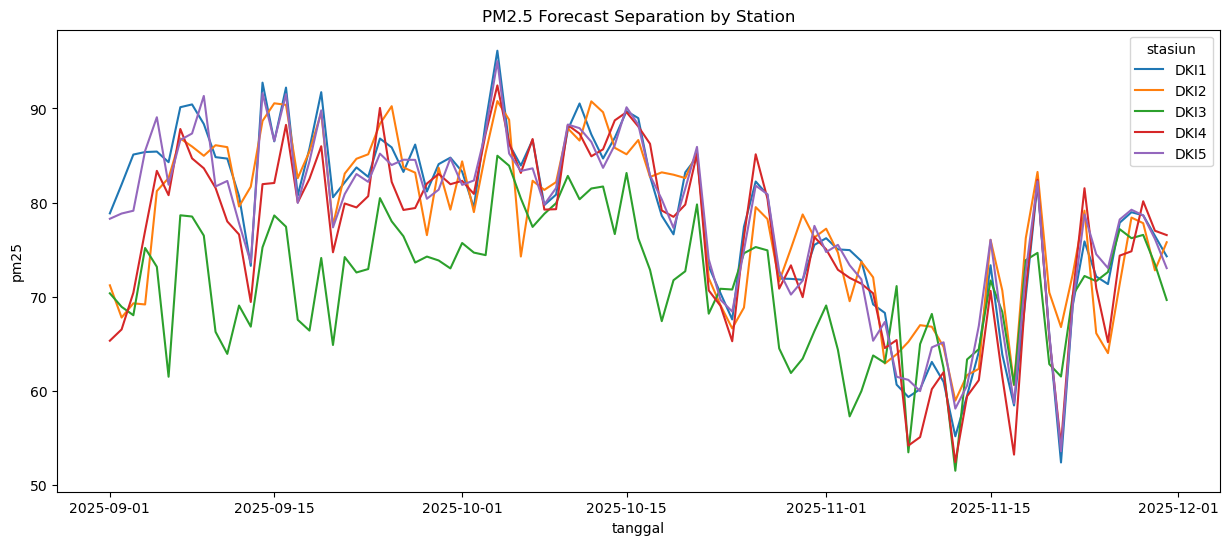

In [6]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_pred, x='tanggal', y='pm25', hue='stasiun')
plt.title('PM2.5 Forecast Separation by Station')
plt.show()